# Conformations of cyclohexane

Reference: [Visualize Organic Chemistry](https://visualizeorgchem.com/animations/cyclohexane-conformers/)

In [1]:
%load_ext autoreload
%autoreload 2

In [19]:
from ase.io import read
from pyscf import gto
import numpy as np

#  Read the XYZ file with ASE
xyz_file = 'cyclohexane_chair-flip.xyz'  # Path to your XYZ file
molecules = read(xyz_file, index=':')  # Read all frames as a list of Atoms objects

# Loop through each conformation and create a PySCF Mole object
energies = []
for i, atoms in enumerate(molecules):

    # Get atomic symbols and coordinates
    symbols = atoms.get_chemical_symbols()  # List of atom symbols (e.g., ['C', 'C', ..., 'H'])
    coords = atoms.get_positions()

    # Create PySCF Mole object
    mol = gto.Mole()
    mol.atom = [[symbol, coord] for symbol, coord in zip(symbols, coords)] 
    mol.basis = 'sto-3g'  # Minimal basis set 
    mol.charge = 0  # Neutral molecule
    mol.spin = 0  # Singlet state (cyclohexane is closed-shell)
    
    mol.verbose = 0
    mol.build()  # Build the Mole object

    #  Perform a simple Hartree-Fock calculation
    mf = mol.RHF().run()  # Run Hartree-Fock calculation
    energy = mf.e_tot  # Get total energy
    print(f"Conformation {i + 1} Energy (Hartree): {energy}")

    energies.append(energy)

Conformation 1 Energy (Hartree): -231.4808095343531
Conformation 2 Energy (Hartree): -231.4806429374595
Conformation 3 Energy (Hartree): -231.48035246272298
Conformation 4 Energy (Hartree): -231.47993574326662
Conformation 5 Energy (Hartree): -231.47939874244594
Conformation 6 Energy (Hartree): -231.47874861423853
Conformation 7 Energy (Hartree): -231.47799189625132
Conformation 8 Energy (Hartree): -231.4771393623293
Conformation 9 Energy (Hartree): -231.47620137422885
Conformation 10 Energy (Hartree): -231.47519110997774
Conformation 11 Energy (Hartree): -231.4741238600651
Conformation 12 Energy (Hartree): -231.47301695307993
Conformation 13 Energy (Hartree): -231.47188550012964
Conformation 14 Energy (Hartree): -231.47074762131626
Conformation 15 Energy (Hartree): -231.46962316717264
Conformation 16 Energy (Hartree): -231.46853032417667
Conformation 17 Energy (Hartree): -231.4674883896528
Conformation 18 Energy (Hartree): -231.4665130415363
Conformation 19 Energy (Hartree): -231.4656

In [20]:
with open('cyclohexane_hf_energies.npy', 'wb') as f:
    np.save(f, np.array(energies))

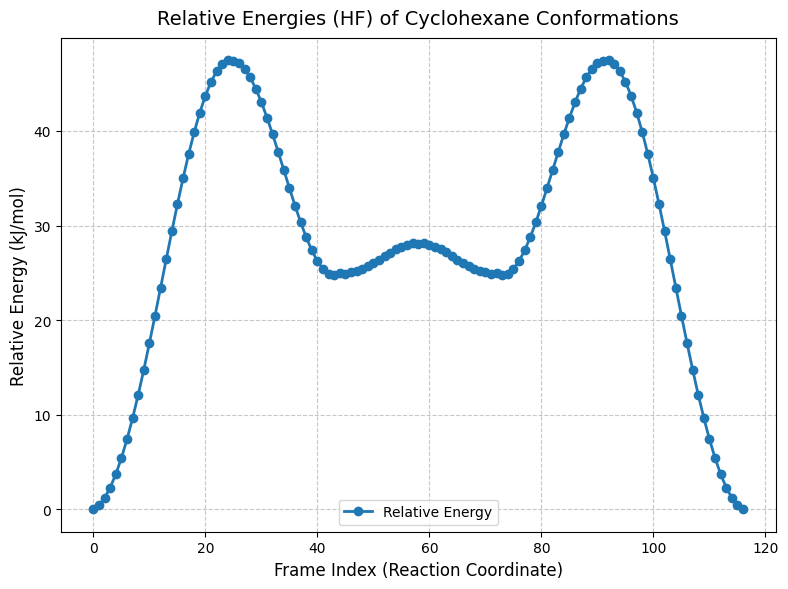

In [21]:
import matplotlib.pyplot as plt

energies_kjmol = np.array(energies) * 2625.5
rel_energies = ((energies_kjmol) - energies_kjmol[0])

plt.figure(figsize=(8, 6))  # Set figure size for better readability
plt.plot(rel_energies, marker='o', linestyle='-', linewidth=2, markersize=6, label='Relative Energy')
plt.xlabel('Frame Index (Reaction Coordinate)', fontsize=12)
plt.ylabel('Relative Energy (kJ/mol)', fontsize=12)
plt.title('Relative Energies (HF) of Cyclohexane Conformations', fontsize=14, pad=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

| Conformer | Index |
| ---------- | ------- |
|   Chair         |   0      |
|      Half-Chair      |    24     |
|   Twist-Boat         |    42     |
| Boat       | 58     |